# Transcriptor factor all

In [1]:
import scanpy as sc
import decoupler as dc

# Only needed for processing
import numpy as np
import pandas as pd
from anndata import AnnData
import pandas as pd
import yaml

In [2]:
def plot_personalize_bars(tf_df, title="", top=20, 
                          lFCs_thr=0.5, sig_thr=0.05,
                          sig = 'padj', title_fontsize=14, 
                          figsize=(5, 5), vertical=True):
    # Generate the volcano plot


    fig = dc.plot_barplot(
        acts=tf_df,
        contrast=comparison,
        top=top,
        vertical=True,
        figsize=figsize,
        dpi=100,
        return_fig=True
    )
    
    # Access the Axes object from the figure
    ax = fig.gca()
    
    # Add a title and remove the outer black line
    ax.set_title(title, fontsize=title_fontsize)
    for spine in ax.spines.values():
        spine.set_visible(False)  # Hide all outer spines
    
    return fig, ax


In [3]:
pvalue = 0.1

In [4]:
dds_dict = {'ridge':'../data/feature_importance_ridge_smote_7b_SYMBOLS.csv',
           'catboost':'../data/feature_importance_smote_catboost_7b_gene_ranking_07.csv'}

In [5]:
tf_dict = {}
for dds in dds_dict.keys():
    comparison = dds[:-5]
    file = f'results/tf_acts_{comparison}.csv'
    tf_df = pd.read_csv(file, index_col=0)
    tf_dict[dds]=tf_df.copy()

In [6]:
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib import rcParams
import seaborn as sns
import matplotlib.pyplot as plt

ridge
['PAX7', 'NFIX', 'HMGB2', 'PPARGC1A', 'GATA5', 'HESX1', 'ZBTB4', 'HEY2', 'ZFPM2', 'E2F4']
catboost
[]


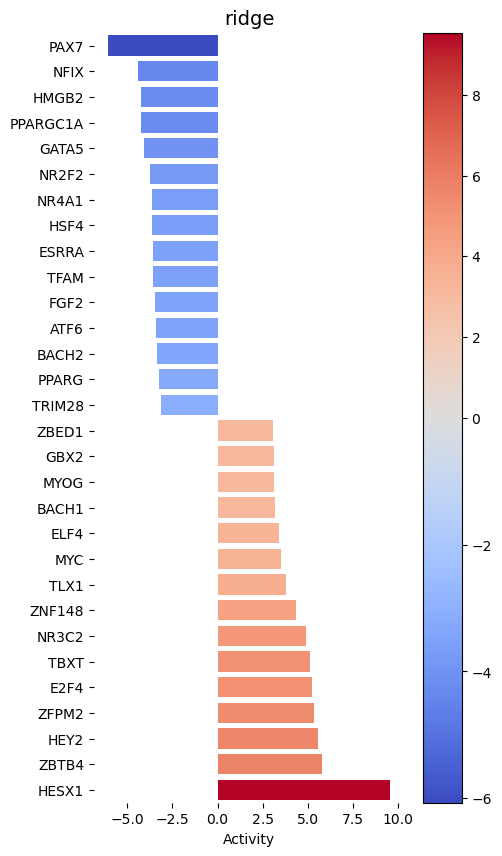

In [7]:
for comparison, tf_df in tf_dict.items():
    print(comparison)
    tf_df = tf_df[tf_df['pvals']<pvalue]
    tf_acts=pd.DataFrame(tf_df[comparison])
    tf_acts=tf_acts.T
    values = tf_acts.iloc[0]
    down_reg = values.sort_values(ascending=True)[:5].index.to_list()
    up_reg = values.sort_values(ascending=False)[:5].index.to_list()
    up_down_reg = down_reg.copy()
    up_down_reg.extend(up_reg)
    print(up_down_reg)
    if len(up_down_reg)>0:
        fig, ax = plot_personalize_bars(tf_acts, title=comparison, top=30, figsize=(5, 10))
        fig.savefig(f"results/{comparison}_TF_Bar.png", bbox_inches='tight')
    

In [14]:
tf_df= tf_dict['catboost'].sort_values(by='pvals')
tf_acts=pd.DataFrame(tf_df[comparison])
tf_acts=tf_acts.T

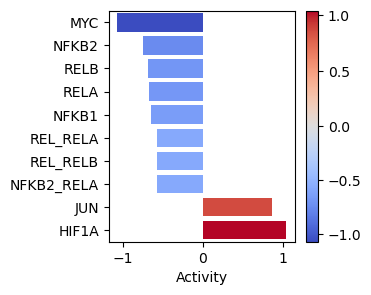

In [15]:
dc.plot_barplot(
    acts=tf_acts,
    contrast=comparison,
    top=10,
    vertical=True,
    figsize=(3, 3)
)

In [ ]:
output_file =  'Transcriptor_factor_plot.pdf'
with PdfPages(output_file) as pdf:
    for comparison, tf_df in tf_dict.items():
        print(comparison)
        tf_df = tf_df[tf_df['pvals']<pvalue]
        tf_acts=pd.DataFrame(tf_df[comparison])
        tf_acts=tf_acts.T
        values = tf_acts.iloc[0]
        down_reg = values.sort_values(ascending=True)[:5].index.to_list()
        up_reg = values.sort_values(ascending=False)[:5].index.to_list()
        up_down_reg = down_reg.copy()
        up_down_reg.extend(up_reg)
        print(up_down_reg)
        if len(up_down_reg)>0:
            fig, ax = plot_personalize_bars(tf_acts, title=comparison, top=30, figsize=(5, 10))           
            # Save the figure to the PDF
            pdf.savefig(fig)
            # Close the figure after saving it to free up memory
            plt.close(fig)


In [ ]:
tf_df

In [ ]:
tf_df = tf_df[tf_df['pvals']<0.1]
tf_acts=pd.DataFrame(tf_df[comparison])
tf_acts=tf_acts.T
tf_acts

In [ ]:
values = tf_acts.iloc[0]
values

In [ ]:
down_reg = values.sort_values(ascending=True)[:5].index.to_list()
up_reg = values.sort_values(ascending=False)[:5].index.to_list()
up_down_reg = down_reg.copy()
up_down_reg.extend(up_reg)
up_down_reg

In [ ]:
dc.plot_barplot(
    acts=tf_acts,
    contrast=comparison,
    top=10,
    vertical=True,
    figsize=(3, 3)
)

In [ ]:
fig, ax = plot_personalize_bars(tf_acts, title=comparison, top=30, figsize=(5, 10))

In [ ]:
fig.savefig(f"results/{experiment}_{comparison}_TF_Bar.png", bbox_inches='tight')


In [ ]:
comparison